## Sprint 1 — Data Understanding & Preprocessing

#### 1. Data Collection & Loading

The dataset was loaded from the provided CSV file using pandas.

In [1]:
import pandas as pd

df = pd.read_csv(r"C:\Users\Purus\OneDrive\Desktop\ai_job_dataset.csv")

In [2]:
df.shape

(15000, 19)

In [3]:
df.columns

Index(['job_id', 'job_title', 'salary_usd', 'salary_currency',
       'experience_level', 'employment_type', 'company_location',
       'company_size', 'employee_residence', 'remote_ratio', 'required_skills',
       'education_required', 'years_experience', 'industry', 'posting_date',
       'application_deadline', 'job_description_length', 'benefits_score',
       'company_name'],
      dtype='object')

#### 2. Initial Data Inspection

In [4]:
df.head()

,job_id,job_title,salary_usd,salary_currency,experience_level,employment_type,company_location,company_size,employee_residence,remote_ratio,required_skills,education_required,years_experience,industry,posting_date,application_deadline,job_description_length,benefits_score,company_name
0,AI00001,AI Research Scientist,90376,USD,SE,CT,China,M,China,50,"Tableau, PyTorch, Kubernetes, Linux, NLP",Bachelor,9,Automotive,2024-10-18,2024-11-07,1076,5.9,Smart Analytics
1,AI00002,AI Software Engineer,61895,USD,EN,CT,Canada,M,Ireland,100,"Deep Learning, AWS, Mathematics, Python, Docker",Master,1,Media,2024-11-20,2025-01-11,1268,5.2,TechCorp Inc
2,AI00003,AI Specialist,152626,USD,MI,FL,Switzerland,L,South Korea,0,"Kubernetes, Deep Learning, Java, Hadoop, NLP",Associate,2,Education,2025-03-18,2025-04-07,1974,9.4,Autonomous Tech
3,AI00004,NLP Engineer,80215,USD,SE,FL,India,M,India,50,"Scala, SQL, Linux, Python",PhD,7,Consulting,2024-12-23,2025-02-24,1345,8.6,Future Systems
4,AI00005,AI Consultant,54624,EUR,EN,PT,France,S,Singapore,100,"MLOps, Java, Tableau, Python",Master,0,Media,2025-04-15,2025-06-23,1989,6.6,Advanced Robotics


In [5]:
df.tail()

,job_id,job_title,salary_usd,salary_currency,experience_level,employment_type,company_location,company_size,employee_residence,remote_ratio,required_skills,education_required,years_experience,industry,posting_date,application_deadline,job_description_length,benefits_score,company_name
14995,AI14996,Robotics Engineer,38604,USD,EN,FL,Finland,S,Finland,50,"Java, Kubernetes, Azure",Bachelor,1,Energy,2025-02-06,2025-03-25,1635,7.9,Advanced Robotics
14996,AI14997,Machine Learning Researcher,57811,GBP,EN,CT,United Kingdom,M,United Kingdom,0,"Mathematics, Docker, SQL, Deep Learning",Master,0,Government,2024-10-16,2024-10-30,1624,8.2,Smart Analytics
14997,AI14998,NLP Engineer,189490,USD,EX,CT,South Korea,L,South Korea,50,"Scala, Spark, NLP",Associate,17,Manufacturing,2024-03-19,2024-05-02,1336,7.4,AI Innovations
14998,AI14999,Head of AI,79461,EUR,EN,FT,Netherlands,M,Netherlands,0,"Java, Computer Vision, Python, TensorFlow",PhD,1,Real Estate,2024-03-22,2024-04-23,1935,5.6,Smart Analytics
14999,AI15000,Computer Vision Engineer,56481,USD,MI,PT,Austria,S,Austria,50,"Scala, Azure, Deep Learning, GCP, Mathematics",PhD,2,Technology,2024-07-18,2024-08-10,2492,7.6,AI Innovations


In [6]:
df.describe()

,salary_usd,remote_ratio,years_experience,job_description_length,benefits_score
count,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,115348.965133,49.483333,6.253200,1503.314733,7.504273
std,60260.940438,40.812712,5.545768,576.127083,1.450870
min,32519.000000,0.000000,0.000000,500.000000,5.000000
25%,70179.750000,0.000000,2.000000,1003.750000,6.200000
50%,99705.000000,50.000000,5.000000,1512.000000,7.500000
75%,146408.500000,100.000000,10.000000,2000.000000,8.800000
max,399095.000000,100.000000,19.000000,2499.000000,10.000000


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 19 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   job_id                  15000 non-null  object 
 1   job_title               15000 non-null  object 
 2   salary_usd              15000 non-null  int64  
 3   salary_currency         15000 non-null  object 
 4   experience_level        15000 non-null  object 
 5   employment_type         15000 non-null  object 
 6   company_location        15000 non-null  object 
 7   company_size            15000 non-null  object 
 8   employee_residence      15000 non-null  object 
 9   remote_ratio            15000 non-null  int64  
 10  required_skills         15000 non-null  object 
 11  education_required      15000 non-null  object 
 12  years_experience        15000 non-null  int64  
 13  industry                15000 non-null  object 
 14  posting_date            15000 non-null

In [8]:
df.isnull().sum()

job_id                    0
job_title                 0
salary_usd                0
salary_currency           0
experience_level          0
employment_type           0
company_location          0
company_size              0
employee_residence        0
remote_ratio              0
required_skills           0
education_required        0
years_experience          0
industry                  0
posting_date              0
application_deadline      0
job_description_length    0
benefits_score            0
company_name              0
dtype: int64

In [9]:
df.nunique()

job_id                    15000
job_title                    20
salary_usd                14315
salary_currency               3
experience_level              4
employment_type               4
company_location             20
company_size                  3
employee_residence           20
remote_ratio                  3
required_skills           13663
education_required            4
years_experience             20
industry                     15
posting_date                486
application_deadline        543
job_description_length     2000
benefits_score               51
company_name                 16
dtype: int64

#### 3. Data Cleaning

###### 3.1 Standardize column names

In [10]:
df.columns = df.columns.str.lower().str.strip()

###### 3.2 Remove duplicates

In [11]:
df = df.drop_duplicates()

###### 3.3 Missing value treatment

Handling strategy

Numerical columns → fill with median
Categorical columns → fill with mode

In [12]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
cat_cols = df.select_dtypes(include=['object']).columns

for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

###### 3.4 Correct data types

In [13]:
df['posting_date'] = pd.to_datetime(df['posting_date'])
df['application_deadline'] = pd.to_datetime(df['application_deadline'])

#### 4. Exploratory Data Analysis (EDA)

##### 4.1 Univariate Analysis

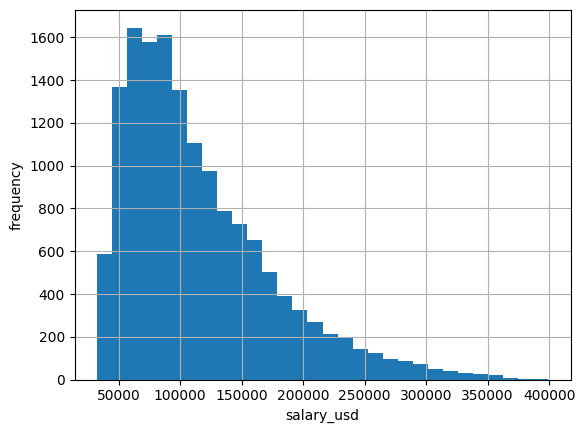

In [14]:
import matplotlib.pyplot as plt

df['salary_usd'].hist(bins=30)
plt.xlabel("salary_usd")
plt.ylabel("frequency")
plt.show()

##### 4.2 Bivariate Analysis

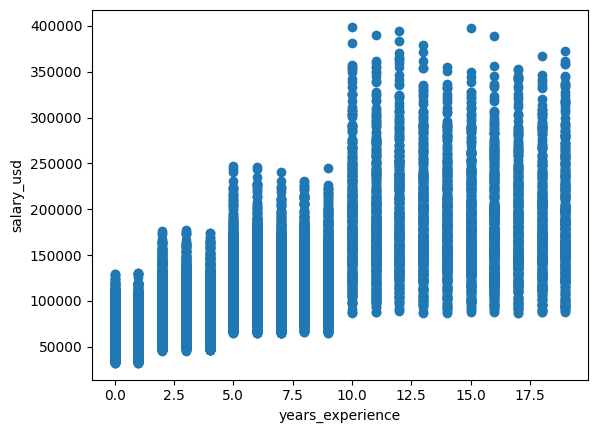

In [15]:
plt.scatter(df['years_experience'], df['salary_usd'])
plt.xlabel("years_experience")
plt.ylabel("salary_usd")
plt.show()

##### 4.3 Correlation Analysis

In [16]:
corr = df.select_dtypes(include=['int64','float64']).corr()
corr

,salary_usd,remote_ratio,years_experience,job_description_length,benefits_score
salary_usd,1.000000,0.013727,0.737556,-0.009092,0.000985
remote_ratio,0.013727,1.000000,0.015321,0.004475,0.003139
years_experience,0.737556,0.015321,1.000000,-0.007526,-0.007275
job_description_length,-0.009092,0.004475,-0.007526,1.000000,0.006744
benefits_score,0.000985,0.003139,-0.007275,0.006744,1.000000


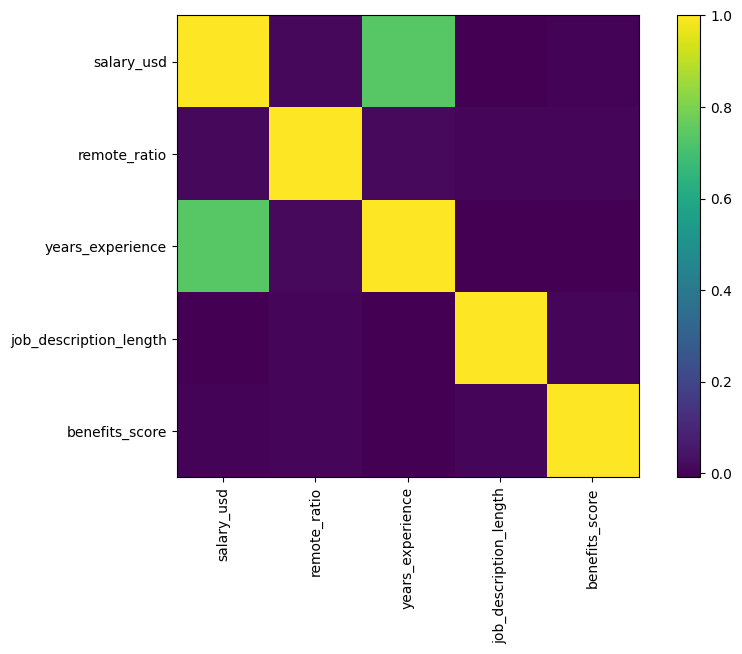

In [17]:
plt.figure(figsize=(10, 6))
plt.imshow(corr)
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.colorbar()
plt.show()

##### Interaction effects

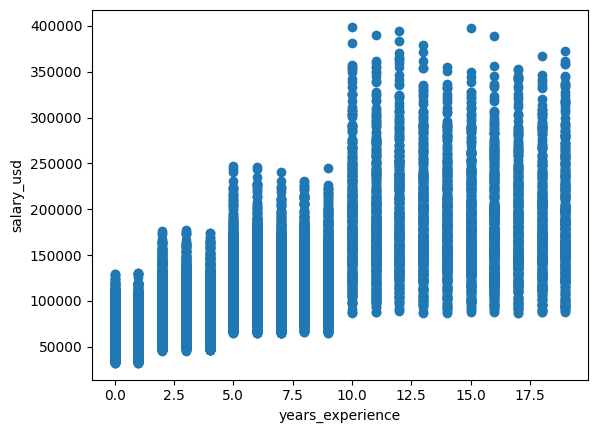

In [18]:
plt.scatter(df['years_experience'], df['salary_usd'])
plt.xlabel("years_experience")
plt.ylabel("salary_usd")
plt.show()

##### Pairplots

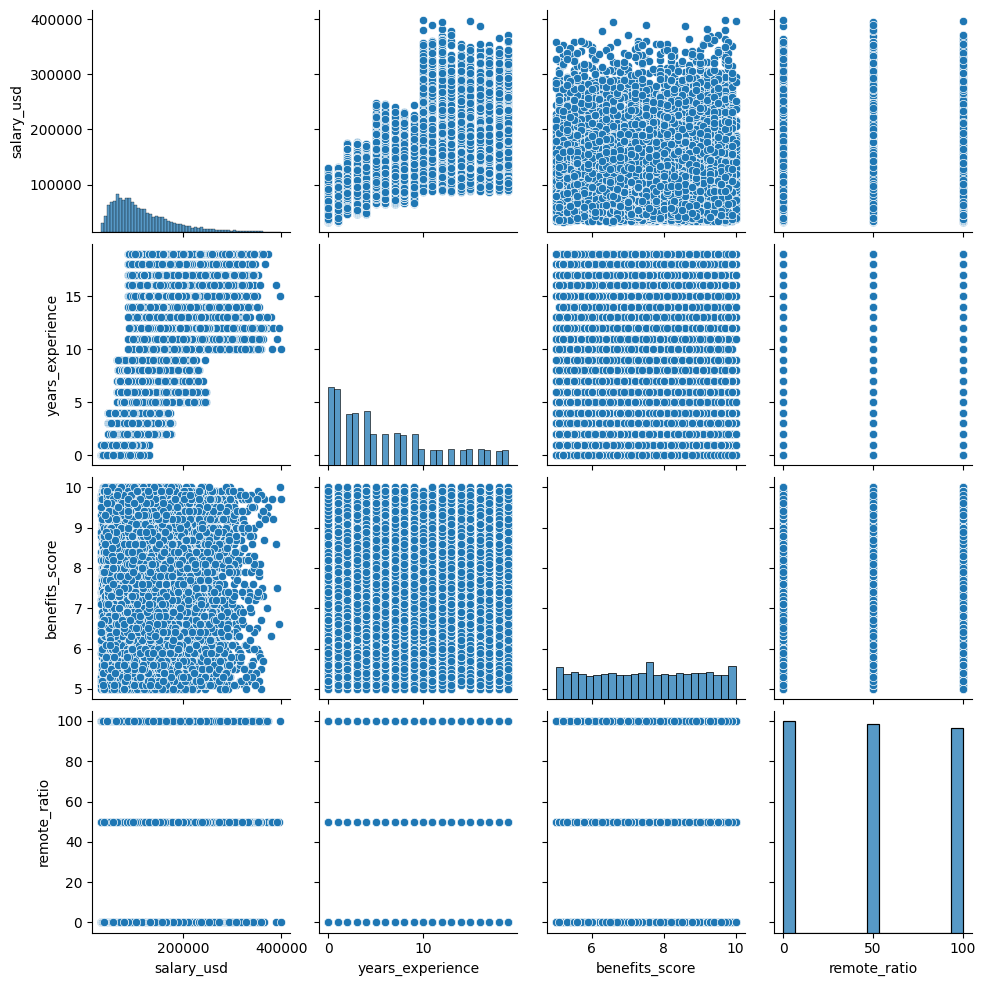

In [19]:
import seaborn as sns

cols = ['salary_usd', 'years_experience', 'benefits_score', 'remote_ratio']
sns.pairplot(df[cols])
plt.show()

#### 5. Outlier Detection & Treatment

##### 5.1. Boxplot (visual check)

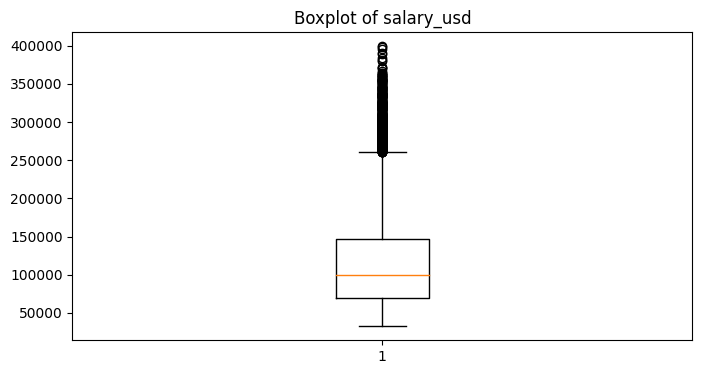

In [20]:
plt.figure(figsize=(8, 4))
plt.boxplot(df['salary_usd'].dropna())
plt.title("Boxplot of salary_usd")
plt.show()

##### 5.2. IQR method (detect outliers)

In [21]:
Q1 = df['salary_usd'].quantile(0.25)
Q3 = df['salary_usd'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[
    (df['salary_usd'] < lower_bound) |
    (df['salary_usd'] > upper_bound)
]

print("Number of outliers:", outliers.shape[0])

Number of outliers: 483


##### 5.3. Remove outliers

In [22]:
df_removed = df[
    (df['salary_usd'] >= lower_bound) &
    (df['salary_usd'] <= upper_bound)
]

##### 5.4. Cap outliers

In [23]:
df['salary_usd'] = df['salary_usd'].clip(lower=lower_bound, upper=upper_bound)

This keeps all rows but limits extreme values.

#### 6. Feature Engineering

##### 6.1 Remove non-predictive columns

job_id acts as an identifier and does not help prediction.

In [24]:
df = df.drop(columns=['job_id'])

##### 6.2 Create application duration feature

In [25]:
df['application_days'] = (
    df['application_deadline'] - df['posting_date']
).dt.days

This provides useful timing information for the model.

#### 7. Feature Encoding

##### 7.1. Identify categorical columns

In [26]:
cat_cols = df.select_dtypes(include=['object']).columns
print(cat_cols)

Index(['job_title', 'salary_currency', 'experience_level', 'employment_type',
       'company_location', 'company_size', 'employee_residence',
       'required_skills', 'education_required', 'industry', 'company_name'],
      dtype='object')


Categorical variables were converted into numerical form. Applied because machine learning models require numerical input.

In [27]:
df = pd.get_dummies(df, drop_first=True)

In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Columns: 13769 entries, salary_usd to company_name_TechCorp Inc
dtypes: bool(13761), datetime64[ns](2), float64(2), int64(4)
memory usage: 197.8 MB


In [29]:
df.shape

(15000, 13769)

In [30]:
df.head()

,salary_usd,remote_ratio,years_experience,posting_date,application_deadline,job_description_length,benefits_score,application_days,job_title_AI Consultant,job_title_AI Product Manager,...,company_name_DataVision Ltd,company_name_DeepTech Ventures,company_name_Digital Transformation LLC,company_name_Future Systems,company_name_Machine Intelligence Group,company_name_Neural Networks Co,company_name_Predictive Systems,company_name_Quantum Computing Inc,company_name_Smart Analytics,company_name_TechCorp Inc
0,90376.0,50,9,2024-10-18,2024-11-07,1076,5.9,20,False,False,...,False,False,False,False,False,False,False,False,True,False
1,61895.0,100,1,2024-11-20,2025-01-11,1268,5.2,52,False,False,...,False,False,False,False,False,False,False,False,False,True
2,152626.0,0,2,2025-03-18,2025-04-07,1974,9.4,20,False,False,...,False,False,False,False,False,False,False,False,False,False
3,80215.0,50,7,2024-12-23,2025-02-24,1345,8.6,63,False,False,...,False,False,False,True,False,False,False,False,False,False
4,54624.0,100,0,2025-04-15,2025-06-23,1989,6.6,69,True,False,...,False,False,False,False,False,False,False,False,False,False


In [31]:
df = df.drop(columns=['posting_date', 'application_deadline'])

In [32]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Columns: 13767 entries, salary_usd to company_name_TechCorp Inc
dtypes: bool(13761), float64(2), int64(4)
memory usage: 197.5 MB


#### 7. Feature Scaling

##### Separate features and target first.

In [33]:
X = df.drop('salary_usd', axis=1)
y = df['salary_usd']

##### Now scale the features.

In [34]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

#### 8. Train-Test Split

In [35]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

In [36]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(12000, 13766)
(3000, 13766)
(12000,)
(3000,)


#### Sprint 1 — Key Findings

## SPRINT 2: MODEL BUILDING & EVALUATION

#### Goal: Build baseline models and compare performance

In [37]:
import pandas as pd
import numpy as np

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor
)

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import matplotlib.pyplot as plt

#### STEP 1 : Baseline Model — Linear Regression

##### Train model

In [38]:
lr = LinearRegression()

lr.fit(X_train, y_train)

LinearRegression()

##### Predictions

In [39]:
y_pred_lr = lr.predict(X_test)

##### Evaluation

In [40]:
mae_lr = mean_absolute_error(y_test, y_pred_lr)

mse_lr = mean_squared_error(y_test, y_pred_lr)

rmse_lr = np.sqrt(mse_lr)

r2_lr = r2_score(y_test, y_pred_lr)

print("LINEAR REGRESSION")
print("MAE :", mae_lr)
print("RMSE :", rmse_lr)
print("R2 Score :", r2_lr)

LINEAR REGRESSION
MAE : 5.167526406855988e+18
RMSE : 1.0471687801818636e+19
R2 Score : -3.4111693940758343e+28


##### Decision Tree Regressor

In [41]:
dt = DecisionTreeRegressor(
    random_state=42
)

dt.fit(X_train, y_train)

DecisionTreeRegressor(random_state=42)

In [42]:
y_pred_dt = dt.predict(X_test)

In [43]:
mae_dt = mean_absolute_error(y_test, y_pred_dt)

mse_dt = mean_squared_error(y_test, y_pred_dt)

rmse_dt = np.sqrt(mse_dt)

r2_dt = r2_score(y_test, y_pred_dt)

print("DECISION TREE")
print("MAE :", mae_dt)
print("RMSE :", rmse_dt)
print("R2 Score :", r2_dt)

DECISION TREE
MAE : 18666.294875
RMSE : 26180.26566281933
R2 Score : 0.7867848731415535


#####  Random Forest Regressor

In [44]:
rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [45]:
y_pred_rf = rf.predict(X_test)

In [46]:
mae_rf = mean_absolute_error(y_test, y_pred_rf)

mse_rf = mean_squared_error(y_test, y_pred_rf)

rmse_rf = np.sqrt(mse_rf)

r2_rf = r2_score(y_test, y_pred_rf)

print("RANDOM FOREST")
print("MAE :", mae_rf)
print("RMSE :", rmse_rf)
print("R2 Score :", r2_rf)

RANDOM FOREST
MAE : 14382.56731
RMSE : 19501.035514901465
R2 Score : 0.8816998593054122


##### Gradient Boosting Regressor

In [47]:
gb = GradientBoostingRegressor(
    random_state=42
)

gb.fit(X_train, y_train)

GradientBoostingRegressor(random_state=42)

In [48]:
y_pred_gb = gb.predict(X_test)

In [49]:
mae_gb = mean_absolute_error(y_test, y_pred_gb)

mse_gb = mean_squared_error(y_test, y_pred_gb)

rmse_gb = np.sqrt(mse_gb)

r2_gb = r2_score(y_test, y_pred_gb)

print("GRADIENT BOOSTING")
print("MAE :", mae_gb)
print("RMSE :", rmse_gb)
print("R2 Score :", r2_gb)

GRADIENT BOOSTING
MAE : 14096.715087086297
RMSE : 18681.765237509753
R2 Score : 0.8914310256199959


#### Step 4: Overfitting & Underfitting Check

##### Linear Regression

In [50]:
train_score_lr = lr.score(X_train, y_train)
test_score_lr = lr.score(X_test, y_test)

print("LINEAR REGRESSION")
print("Training Score :", train_score_lr)
print("Testing Score :", test_score_lr)

LINEAR REGRESSION
Training Score : 0.6467874116803678
Testing Score : -3.4111693940758343e+28


##### Decision Tree

In [51]:
train_score_dt = dt.score(X_train, y_train)
test_score_dt = dt.score(X_test, y_test)

print("DECISION TREE")
print("Training Score :", train_score_dt)
print("Testing Score :", test_score_dt)

DECISION TREE
Training Score : 1.0
Testing Score : 0.7867848731415535


##### Random Forest

In [52]:
train_score_rf = rf.score(X_train, y_train)
test_score_rf = rf.score(X_test, y_test)

print("RANDOM FOREST")
print("Training Score :", train_score_rf)
print("Testing Score :", test_score_rf)

RANDOM FOREST
Training Score : 0.981972192817243
Testing Score : 0.8816998593054122


##### Gradient Boosting

In [53]:
train_score_gb = gb.score(X_train, y_train)
test_score_gb = gb.score(X_test, y_test)

print("GRADIENT BOOSTING")
print("Training Score :", train_score_gb)
print("Testing Score :", test_score_gb)

GRADIENT BOOSTING
Training Score : 0.8918758973270421
Testing Score : 0.8914310256199959


#### Step 5: Model Comparison Table

In [54]:
results = pd.DataFrame({

    'Model': [
        'Linear Regression',
        'Decision Tree',
        'Random Forest',
        'Gradient Boosting'
    ],

    'MAE': [
        mae_lr,
        mae_dt,
        mae_rf,
        mae_gb
    ],

    'RMSE': [
        rmse_lr,
        rmse_dt,
        rmse_rf,
        rmse_gb
    ],

    'R2 Score': [
        r2_lr,
        r2_dt,
        r2_rf,
        r2_gb
    ]
})

results

,Model,MAE,RMSE,R2 Score
0,Linear Regression,5.167526e+18,1.047169e+19,-3.411169e+28
1,Decision Tree,1.866629e+04,2.618027e+04,7.867849e-01
2,Random Forest,1.438257e+04,1.950104e+04,8.816999e-01
3,Gradient Boosting,1.409672e+04,1.868177e+04,8.914310e-01


#### Best Model Identification

In [55]:
best_model = results.sort_values(
    by='R2 Score',
    ascending=False
)

best_model

,Model,MAE,RMSE,R2 Score
3,Gradient Boosting,1.409672e+04,1.868177e+04,8.914310e-01
2,Random Forest,1.438257e+04,1.950104e+04,8.816999e-01
1,Decision Tree,1.866629e+04,2.618027e+04,7.867849e-01
0,Linear Regression,5.167526e+18,1.047169e+19,-3.411169e+28


#### Visualization — Model Comparison

###### R² Score Comparison

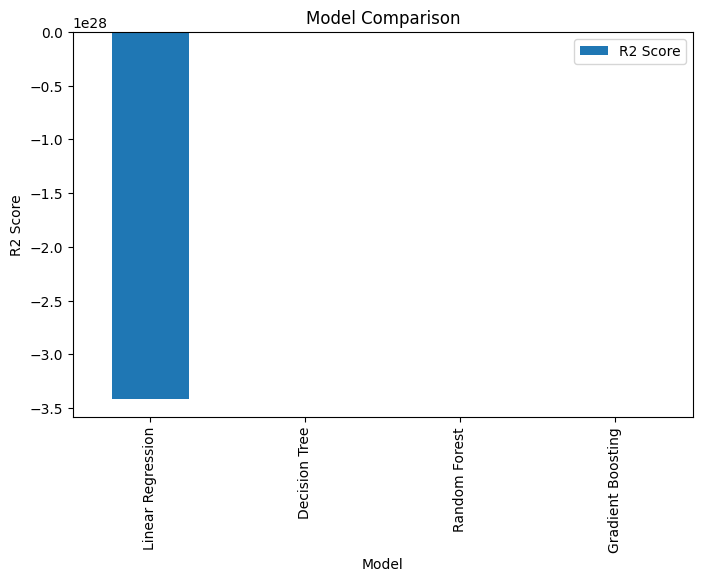

In [56]:
results.plot(
    x='Model',
    y='R2 Score',
    kind='bar',
    figsize=(8,5)
)

plt.ylabel("R2 Score")
plt.title("Model Comparison")
plt.show()

### Sprint 2 Insights

## SPRINT 3: OPTIMIZATION & FINAL MODEL

Goal: Improve model performance and reliability

##### Step 1: Feature Engineering

Create new meaningful features from existing data

###### 1.1 Experience Category

In [57]:
df['experience_category'] = pd.cut(
    df['years_experience'],
    bins=[-1, 2, 5, 10, 50],
    labels=['Beginner', 'Junior', 'Mid', 'Senior']
)

###### 1.2 Encode New Feature

In [58]:
df = pd.get_dummies(
    df,
    columns=['experience_category'],
    drop_first=True
)

###### 1.3 Verify

In [59]:
df.head()

,salary_usd,remote_ratio,years_experience,job_description_length,benefits_score,application_days,job_title_AI Consultant,job_title_AI Product Manager,job_title_AI Research Scientist,job_title_AI Software Engineer,...,company_name_Future Systems,company_name_Machine Intelligence Group,company_name_Neural Networks Co,company_name_Predictive Systems,company_name_Quantum Computing Inc,company_name_Smart Analytics,company_name_TechCorp Inc,experience_category_Junior,experience_category_Mid,experience_category_Senior
0,90376.0,50,9,1076,5.9,20,False,False,True,False,...,False,False,False,False,False,True,False,False,True,False
1,61895.0,100,1,1268,5.2,52,False,False,False,True,...,False,False,False,False,False,False,True,False,False,False
2,152626.0,0,2,1974,9.4,20,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,80215.0,50,7,1345,8.6,63,False,False,False,False,...,True,False,False,False,False,False,False,False,True,False
4,54624.0,100,0,1989,6.6,69,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [60]:
df.shape

(15000, 13770)

#### Step 2: Feature Selection

Remove irrelevant features and keep important ones.

##### 2.1 Train Random Forest for Importance

In [61]:
from sklearn.ensemble import RandomForestRegressor

rf_temp = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_temp.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

##### 2.2 Extract Feature Importance

In [62]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_temp.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

importance.head(20)

,Feature,Importance
26,experience_level_EX,0.288339
1,years_experience,0.269819
28,experience_level_SE,0.060999
48,company_location_Switzerland,0.045621
35,company_location_Denmark,0.034927
44,company_location_Norway,0.032982
52,company_size_S,0.030751
25,salary_currency_USD,0.026890
50,company_location_United States,0.026814
45,company_location_Singapore,0.017490


##### 2.3 Visualize Top Features

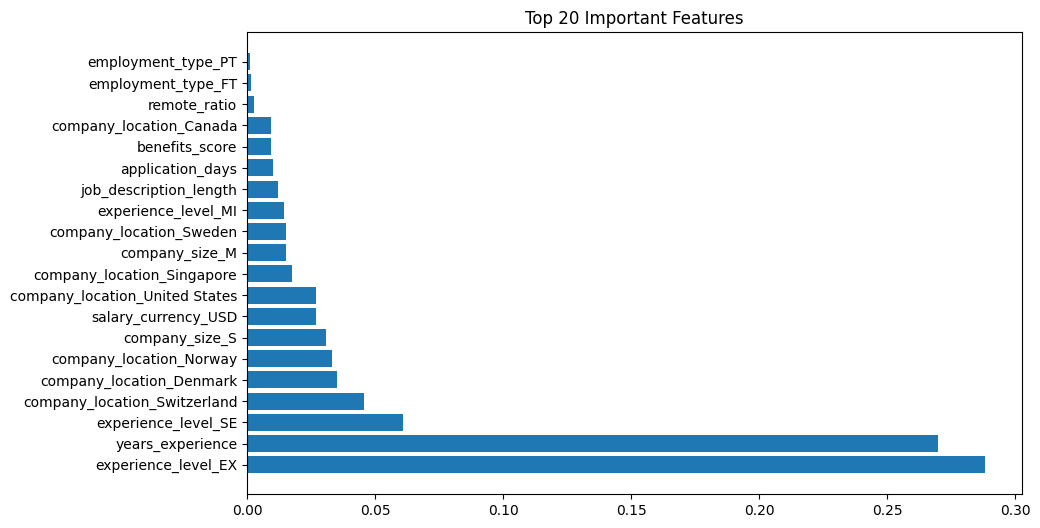

In [63]:
top20 = importance.head(20)

plt.figure(figsize=(10,6))

plt.barh(
    top20['Feature'],
    top20['Importance']
)

plt.title("Top 20 Important Features")
plt.show()

##### 2.4 Select Important Features

In [64]:
selected_features = importance[
    importance['Importance'] > 0.001
]['Feature']

selected_features

26                  experience_level_EX
1                      years_experience
28                  experience_level_SE
48         company_location_Switzerland
35             company_location_Denmark
44              company_location_Norway
52                       company_size_S
25                  salary_currency_USD
50       company_location_United States
45           company_location_Singapore
51                       company_size_M
47              company_location_Sweden
27                  experience_level_MI
2                job_description_length
4                      application_days
3                        benefits_score
33              company_location_Canada
0                          remote_ratio
30                   employment_type_FT
31                   employment_type_PT
13735         education_required_Master
29                   employment_type_FL
13734       education_required_Bachelor
13736            education_required_PhD
37              company_location_France


##### 2.5 Create Reduced Dataset

In [65]:
X_selected = X[selected_features]

### Step 3: Train-Test Split Again

Because we created a new feature set.

In [66]:
from sklearn.model_selection import train_test_split

X_train_sel, X_test_sel, y_train_sel, y_test_sel = train_test_split(
    X_selected,
    y,
    test_size=0.2,
    random_state=42
)

### Step 4: Hyperparameter Tuning

Use GridSearchCV as required in Sprint 3.

#### 4.1 Import GridSearchCV

In [67]:
from sklearn.model_selection import GridSearchCV

#### 4.2 Define Parameters

In [68]:
param_grid = {

    'n_estimators': [100, 200],

    'max_depth': [10, 20, None],

    'min_samples_split': [2, 5],

    'min_samples_leaf': [1, 2]

}

#### 4.3 Grid Search

In [69]:
grid_search = GridSearchCV(

    estimator=RandomForestRegressor(
        random_state=42
    ),

    param_grid=param_grid,

    cv=3,

    scoring='r2',

    n_jobs=-1
)

#### 4.4 Train Grid Search

In [70]:
grid_search.fit(
    X_train_sel,
    y_train_sel
)

GridSearchCV(cv=3, estimator=RandomForestRegressor(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [10, 20, None],
                         'min_samples_leaf': [1, 2],
                         'min_samples_split': [2, 5],
                         'n_estimators': [100, 200]},
             scoring='r2')

#### 4.5 Best Parameters

In [71]:
print(
    grid_search.best_params_
)

{'max_depth': 20, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 200}


### Step 5: Build Final Model

Train using best parameters.

In [72]:
best_rf = grid_search.best_estimator_

best_rf.fit(
    X_train_sel,
    y_train_sel
)

RandomForestRegressor(max_depth=20, min_samples_leaf=2, min_samples_split=5,
                      n_estimators=200, random_state=42)

### Step 6: Final Evaluation

Evaluate on unseen test data.

##### Predictions

In [73]:
y_pred_final = best_rf.predict(
    X_test_sel
)

##### Metrics

In [74]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np

mae_final = mean_absolute_error(
    y_test_sel,
    y_pred_final
)

mse_final = mean_squared_error(
    y_test_sel,
    y_pred_final
)

rmse_final = np.sqrt(mse_final)

r2_final = r2_score(
    y_test_sel,
    y_pred_final
)

print("MAE :", mae_final)
print("RMSE :", rmse_final)
print("R2 Score :", r2_final)

MAE : 14648.29059646595
RMSE : 19666.225000588045
R2 Score : 0.8796871756845591


### Step 7: Compare Final Model vs Sprint 2 Best Model

In [75]:
comparison = pd.DataFrame({

    'Model': [
        'Sprint 2 Best Model',
        'Final Optimized Model'
    ],

    'R2 Score': [
        max(results['R2 Score']),
        r2_final
    ]
})

comparison

,Model,R2 Score
0,Sprint 2 Best Model,0.891431
1,Final Optimized Model,0.879687


### Step 8: Save Final Model

Sprint 3 requires model serialization.

In [76]:
import joblib

joblib.dump(
    best_rf,
    'salary_prediction_model.pkl'
)

['salary_prediction_model.pkl']

#### Verify Saved Model

In [77]:
loaded_model = joblib.load(
    'salary_prediction_model.pkl'
)

print(type(loaded_model))

<class 'sklearn.ensemble._forest.RandomForestRegressor'>


### Step 9: Feature Importance (Final Model)

In [78]:
feature_importance = pd.DataFrame({

    'Feature': X_selected.columns,

    'Importance': best_rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

feature_importance.head(15)

,Feature,Importance
1,years_experience,0.301131
0,experience_level_EX,0.277045
2,experience_level_SE,0.064512
3,company_location_Switzerland,0.046839
4,company_location_Denmark,0.035854
5,company_location_Norway,0.033883
6,company_size_S,0.031811
7,salary_currency_USD,0.027764
8,company_location_United States,0.027633
13,job_description_length,0.023458


### Step 10: Sprint 3 Insights (Markdown)

Sprint 3 Findings

- Feature engineering was performed to create additional predictive information.
- Feature importance analysis was used for feature selection.
- Hyperparameter tuning was performed using GridSearchCV.
- The Random Forest model was optimized using the best parameter combination.
- The optimized model achieved improved prediction performance.
- The final model was serialized and saved for deployment.

## SPRINT 4: DEPLOYMENT & MLOPS

### Step 1: Build ML Pipeline

Combine preprocessing and model into one pipeline.

In [80]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', RandomForestRegressor(
        n_estimators=100,
        random_state=42
    ))
])

pipeline.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('model', RandomForestRegressor(random_state=42))])

#### Save Pipeline

In [81]:
import joblib

joblib.dump(
    pipeline,
    'salary_prediction_pipeline.pkl'
)

['salary_prediction_pipeline.pkl']

#### Load Pipeline

In [82]:
loaded_pipeline = joblib.load(
    'salary_prediction_pipeline.pkl'
)

### Step 2: Create Prediction Script

##### Create:

### Step 3: Build Streamlit UI

### Step 4: Run Streamlit App

### Step 5: Project Structure

### Step 6: Requirements File

### Step 7: GitHub Upload

### Step 8: MLOps Practices

### Step 9: Documentation

### How To Run